# TIME SERIES HANDSON

# Time Series

A sequence of data collected over a regular interval of time. Ex- Hour vise stock prices, Daily Temp, Monthly Sales, Yearly Population.

# Time Series Forecasting

using the past time series data to predict/forecast the future data. Guessing the future based on the past.

Ex: Forecasting the sales, Stocks, population, No* of patients in coivid 19, Weather, etc.....

Time series Forecating can be used in Multiple fields:

Finance, Retial, Weather,E-commerce, etc..

In [ ]:
1) Collect the data
2) Data Cleaning and processing
3) Visualize the different components(Trend, Seasonality, Noice)
4) Check Stationary (ADF Test)
5) Make the data stationary(differencing, transforamtions)
6) Train model- ARIMA/ SRIMAX/ etc....
7) Predict the nect n steps(lags)
8) Comapre the prediction with the actual data (RMSE, MAE, .......)
9) Improve the model


Past Data-> Learning Patterns-> Forecasting the Future

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sb

import warnings
warnings.filterwarnings("ignore")

# Air Passengers

https://www.kaggle.com/datasets/chirag19/air-passengers

In [ ]:
data=pd.read_csv("/content/AirPassengers.csv")
data

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
...,...,...
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390


In [ ]:
data.shape

(144, 2)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Month        144 non-null    object
 1   #Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


In [ ]:
data["Month"]=pd.to_datetime(data["Month"])

In [ ]:
data.dtypes

,0
Month,datetime64[ns]
#Passengers,int64


In [ ]:
data.columns=["Month","Passengers"]

### Set the Time Variable as Index

Time series Models expect Time/Date as Index

In [ ]:
data.set_index("Month",inplace=True)
data

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


## Null Values

We have to handle null values because the time series forcasting models cannot generally handel the missing values.

NUll values can occur beacuse of for eg: Sensor Failure, Holiday, Data collection issues, etc...

Before deciding how to handel the null values:

We firstly look for the

- How many null values
- Pattern of nulls
- Frequency of the data(freq of time(monthly, yearly, hourly, seconds, etc)



**Common methods to Handel null values**

1)**Forward Fill**

Ues the pervious values to fill the forward null values.

eg->       10, 20, 30, _

ffill() -> 10,20,30,30

Used when ->

- Data changes slowly
- The last value(observation) is meaning ful.

Used in high freq data ( eg: Stock price over second)


Can't be used when there is a strong trend.

In [ ]:
# data["Value"]= data["Value"].ffill()

**2) Backward Fill**

We use the future / forward valye to fill the backward null vlaue.

eg-> 10,_ ,30

->  10,30,30

USed when future value is more reasonable than the past value.

Used when very small gap, bad for trend.


In [ ]:
# data["Value"]= data["Value"].bfill()

**3) Interpolation**

We estimate the missing values using the nearby known values.

Why the interploation is good:

Preserves trend, continuity, more smooth.

Types:

a) **Linear**

Draws a straight line between the point where the gap starts and ends.

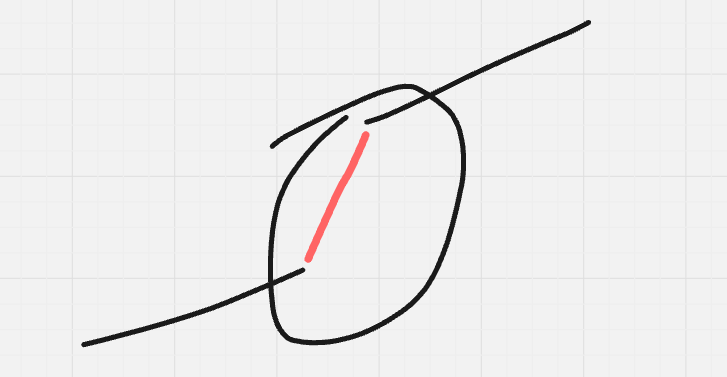



Best when -> The data changes smoothly, there is linear trend, there is no heavy seasonality.


In [ ]:
# data["Value"]=data["Value"].interpolate(method="linear")

**b) Seasonal Interploation**

When seasonality is present.

handels the curvature of data, in a better manner.

In [ ]:
# data["Value"]=data["Value"].interpolate(method="spline")

4)**Rolling Mean/ Moving Average**

Good when noisy data, smooth trends.

**Why not Mean /Median fill**

They are not prefferred beacuse , it destroys the trend/seasonality.

Bad for foreacting

In [ ]:
print(data.isna().sum())

Passengers    0
dtype: int64


## Plot Time Series

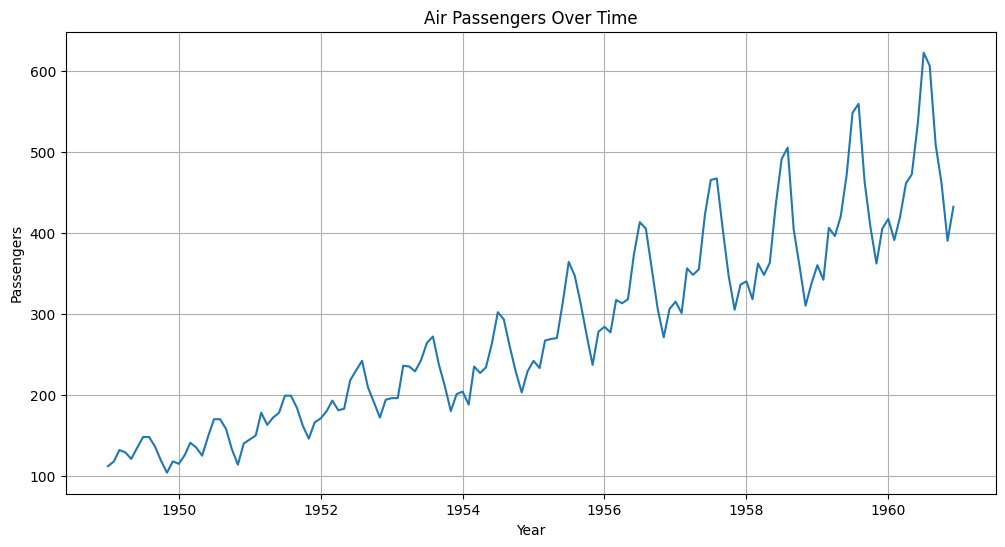

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(data["Passengers"])

plt.title("Air Passengers Over Time")

plt.xlabel("Year")
plt.ylabel("Passengers")

plt.grid()

plt.show()

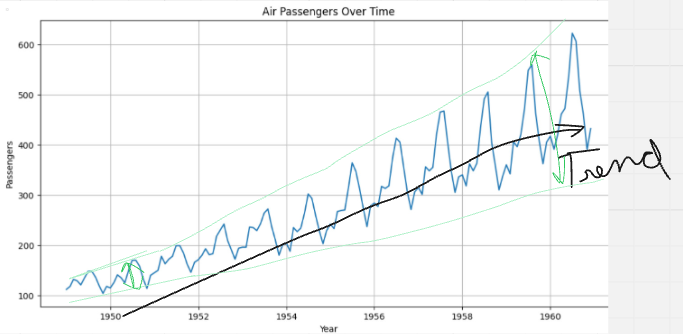

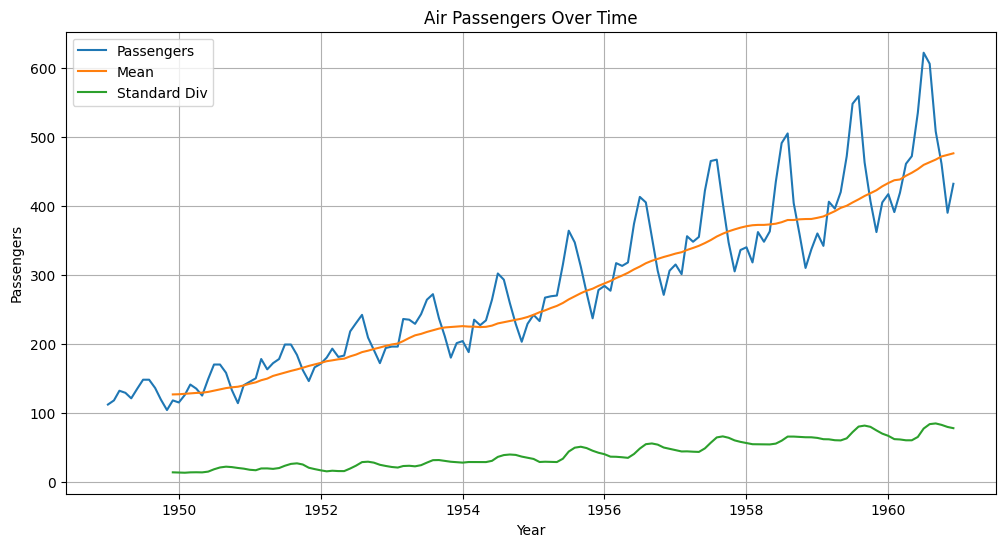

In [ ]:
rolling_mean=data["Passengers"].rolling(window=12).mean()
rolling_std=data["Passengers"].rolling(window=12).std()

plt.figure(figsize=(12,6))

plt.plot(data["Passengers"], label="Passengers")
plt.plot(rolling_mean, label="Mean")
plt.plot(rolling_std, label="Standard Div")

plt.legend()

plt.title("Air Passengers Over Time")

plt.xlabel("Year")
plt.ylabel("Passengers")

plt.grid()

plt.show()


In [ ]:
Interpretation->

Mean and Std is not constant

Assume that-> data is not stationary

## Decomposition

Breaking the time series into the parts(components).

Seeing the Trend, Seasonality and Noice seperately.

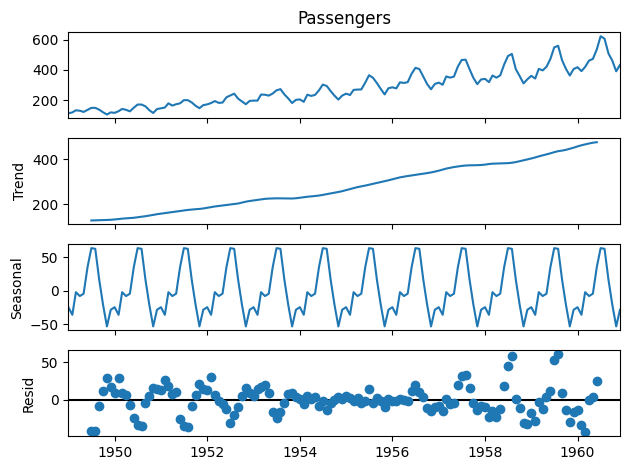

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Perform Decomposition

decomposition = seasonal_decompose(data["Passengers"])

fig= decomposition.plot()

plt.show()

In a stationary data the Noise/Residual Has no pattern(white noise)

## Stationarity

Constant mean, Contanct Variance, Constanct AutoCorrelation.

For better ptrediction/Forecasting the data should be stationary.

And a lot of Forecasting Models assume the data to be stationary.

# ADF Test

Used to check if the data is stationary or Not.

In [ ]:
from statsmodels.tsa.stattools import adfuller

In [ ]:
result = adfuller(data["Passengers"])
result

(np.float64(0.8153688792060498),
 np.float64(0.991880243437641),
 13,
 130,
 {'1%': np.float64(-3.4816817173418295),
  '5%': np.float64(-2.8840418343195267),
  '10%': np.float64(-2.578770059171598)},
 np.float64(996.692930839019))

In [ ]:
# result[0]  -> ADF Statistics ( The more -ve this value is , the more evidence for stationarity)
# result[1]  -> p_value
# result[2]  -> number lags used
# result[4]  -> num for observations used

In [ ]:
p_value=result[1]  # Extract p value from result

# Interpretation
# if p< 0.05    Stationary
#    p> 0.05    Non-Stationary

if p_value<0.05:
  print("Data Is Stationary")
else:
  print("Data is Non-Stationary")

Data is Non-Stationary


# Make the Data Stationary

1) Trend- Differencing

2) Variance- Log , Sqrt, Box-Cox

3) Seasonality- Seasonal differencing

## Transformations

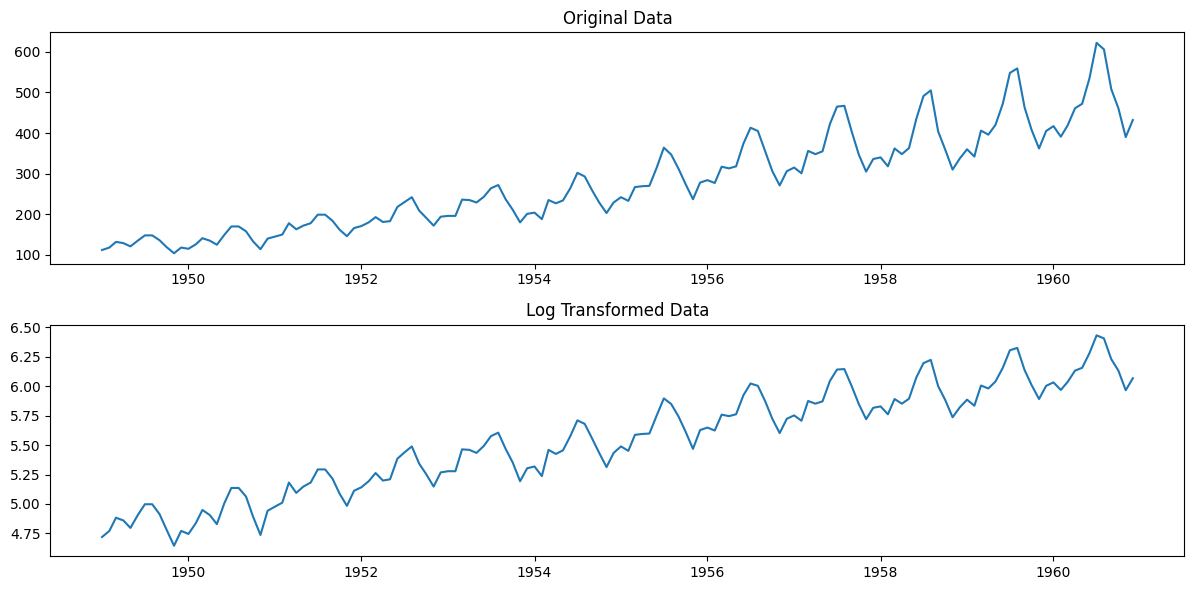

In [ ]:
# Log Transformation

data_log= np.log(data["Passengers"])

plt.figure(figsize=(12,6))

# Original
plt.subplot(2,1,1)
plt.plot(data["Passengers"])
plt.title("Original Data")

# Log transformed data

plt.subplot(2,1,2)
plt.plot(data_log)
plt.title("Log Transformed Data")

plt.tight_layout()
plt.show()

In [ ]:
# Stationariity test of log data

result = adfuller(data_log)
result

p_value=result[1]  # Extract p value from result

# Interpretation
# if p< 0.05    Stationary
#    p> 0.05    Non-Stationary

if p_value<0.05:
  print(p_value)
  print("Data Is Stationary")
else:
  print(p_value)
  print("Data is Non-Stationary")

0.4223667747703874
Data is Non-Stationary


### Box Cox transformation

Automatically finds the best/optimal method to transform the data and make the variance constant.

Checks a lot of different types of transformations(log, sqrt, reciprocal, etc) and finds the best one, and applies it.

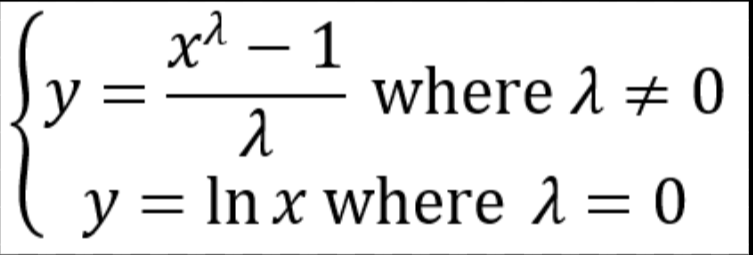

In [ ]:
from scipy.stats import boxcox

# Apply the boxcox method.
# The boxcox model tries different values for the lambda
data_boxcox, lambda_value= boxcox(data["Passengers"])

# Print the lambda

print(lambda_value)

0.1480226858137178


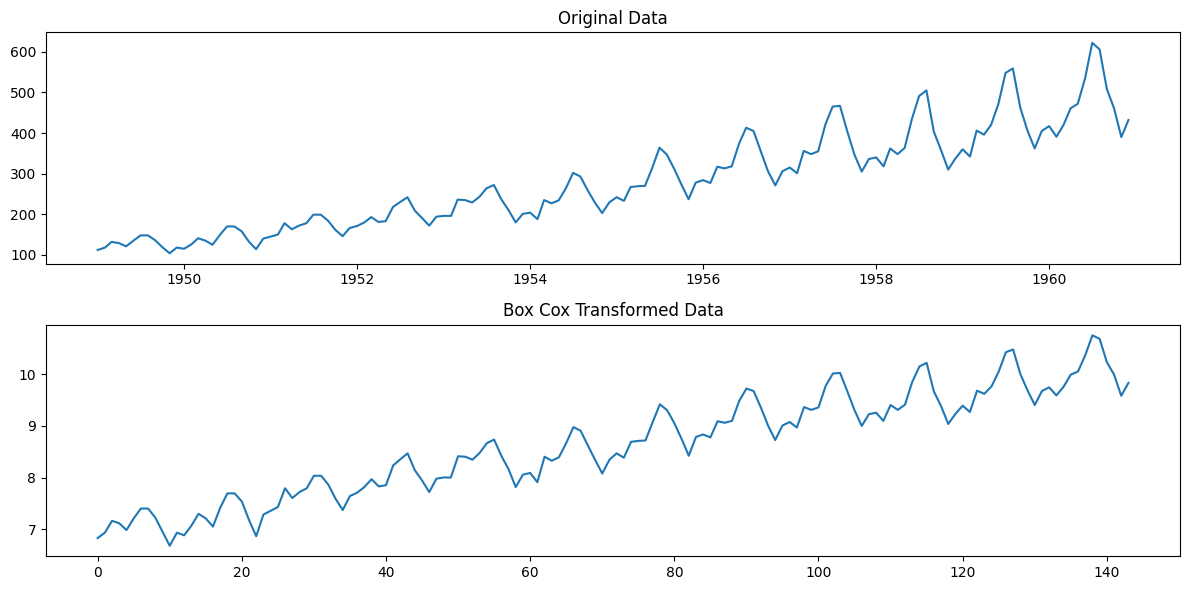

In [ ]:
# Box cox Transformation

data_log= np.log(data["Passengers"])

plt.figure(figsize=(12,6))

# Original
plt.subplot(2,1,1)
plt.plot(data["Passengers"])
plt.title("Original Data")

# Boxcox transformed data

plt.subplot(2,1,2)
plt.plot(data_boxcox)
plt.title("Box Cox Transformed Data")

plt.tight_layout()
plt.show()

In [ ]:
# Stationariity test of boxcox data

result = adfuller(data_boxcox)
result

p_value=result[1]  # Extract p value from result

# Interpretation
# if p< 0.05    Stationary
#    p> 0.05    Non-Stationary

if p_value<0.05:
  print(p_value)
  print("Data Is Stationary")
else:
  print(p_value)
  print("Data is Non-Stationary")

0.617162109223921
Data is Non-Stationary


# Differencing

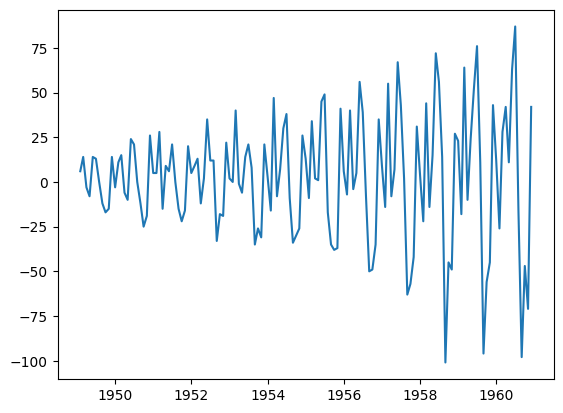

In [ ]:
# First order differencing
diff_data= data.diff()

# Remove the Null values
diff_data.dropna(inplace=True)

plt.plot(diff_data)
plt.show()

In [ ]:
# Stationariity test of boxcox data

result = adfuller(diff_data)
result

p_value=result[1]  # Extract p value from result

# Interpretation
# if p< 0.05    Stationary
#    p> 0.05    Non-Stationary

if p_value<0.05:
  print(p_value)
  print("Data Is Stationary")
else:
  print(p_value)
  print("Data is Non-Stationary")

0.05421329028382478
Data is Non-Stationary


**Combination of Transformation and Differencing**

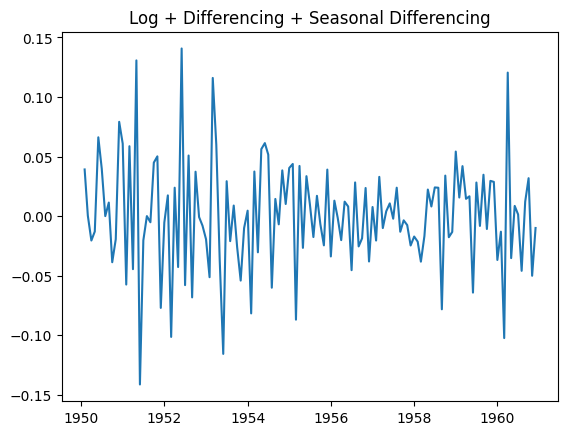

In [ ]:
# Log tranformation

data_log= np.log(data["Passengers"])

# Differencing

data_diff= data_log.diff()

# Seasonal Differencing-> pattern repeats every 12 months

combined_diff= data_diff.diff(12) # Seasonality lag -> 12


# Remove Null
combined_diff.dropna(inplace=True)

df=combined_diff

plt.plot(df)
plt.title("Log + Differencing + Seasonal Differencing")
plt.show()

In [ ]:
# Stationariity test of boxcox data

result = adfuller(df)
result

p_value=result[1]  # Extract p value from result

# Interpretation
# if p< 0.05    Stationary
#    p> 0.05    Non-Stationary

if p_value<0.05:
  print(p_value)
  print("Data Is Stationary")
else:
  print(p_value)
  print("Data is Non-Stationary")

0.00024859123113838495
Data Is Stationary


## Problem

Because of Transformation and Differencing, we have changed the data( changed the scale of data)

So the model forcasting will also be in different scale.

So we have to un-do the transformations in the output, so that it is in the same scale as original.

In [ ]:
# For undo log

Forecast_original = np.exp(forecasting_log)


# ACF and PACF Plots

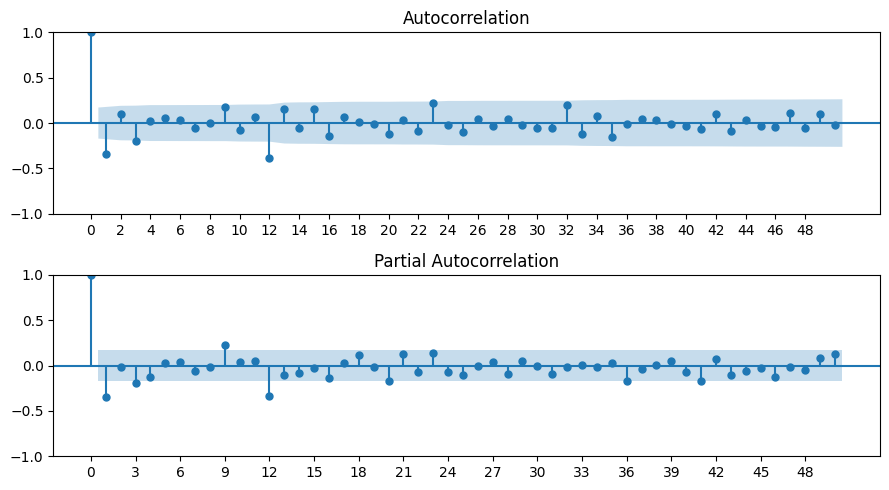

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(9,5))

# ACF  Plot
plt.subplot(2,1,1)
plot_acf(df, ax=plt.gca(), lags=50)
plt.xticks(range(0,50,2))

# PACF Plot
plt.subplot(2,1,2)
plot_pacf(df, ax=plt.gca(), lags=50)
plt.xticks(range(0,50,3))

plt.tight_layout()
plt.show()

# Train Test Split

In [ ]:
# 85, 15 split

# Rows From start(0) to 85% length-1 => Train
train = df.iloc[0 : int(len(df)*0.85)]

# Start from 85% of length go till Last => Test
test= df.iloc[int(len(df)*0.85) : ]

print("Train Shape=",train.shape)
print("Test Shape=",test.shape)

Train Shape= (111,)
Test Shape= (20,)


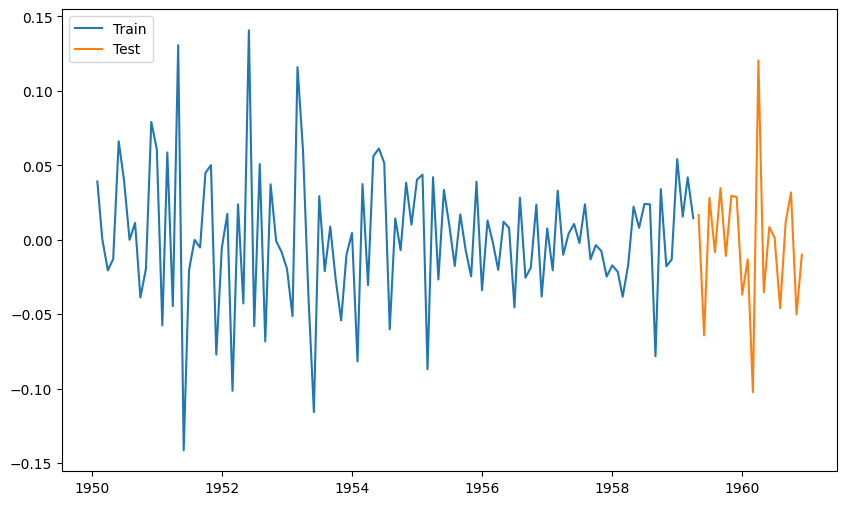

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(train,label="Train")
plt.plot(test, label="Test")

plt.legend()
plt.show()

# ARIMA

Predicts based on the past values as well as the past error terms.

Arima model also differences the data to make it stationary.

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Initilize the model
model= ARIMA(data, order=(p, d, q))

# Train the model
model_fit= model.fit()

# Predictions

pred= model_fit.forecast(steps=) # step-> how many future values to forecas

In [ ]:
p-> AR  ( Used the past values ) (PACF)
q-> MA  ( Used the past errors ) (ACF)
d-> How many differencing you need to make stationary

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Initilize the model
#                        p  d  q
model= ARIMA(train, order=(1,1,1))

# Train the model
model_fit= model.fit()

# Predictions

pred= model_fit.forecast(steps=len(test)) # step-> how many future values to forecast


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [ ]:
print(pred)

1959-05-01   -0.003403
1959-06-01    0.002116
1959-07-01    0.000415
1959-08-01    0.000939
1959-09-01    0.000777
1959-10-01    0.000827
1959-11-01    0.000812
1959-12-01    0.000817
1960-01-01    0.000815
1960-02-01    0.000816
1960-03-01    0.000815
1960-04-01    0.000815
1960-05-01    0.000815
1960-06-01    0.000815
1960-07-01    0.000815
1960-08-01    0.000815
1960-09-01    0.000815
1960-10-01    0.000815
1960-11-01    0.000815
1960-12-01    0.000815
Freq: MS, Name: predicted_mean, dtype: float64


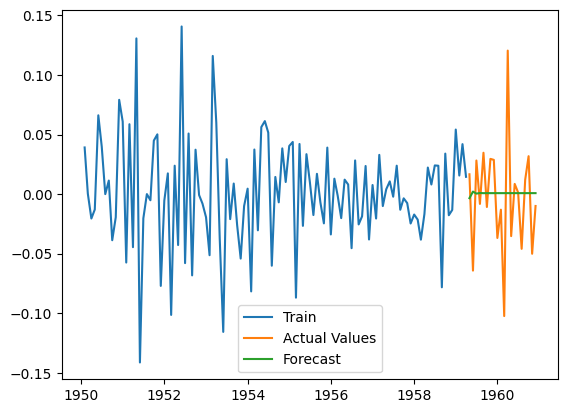

In [ ]:
# Plot the forecasting

plt.plot(train.index, train.values, label="Train")
plt.plot(test.index, test.values, label="Actual Values")
# Plot the forecasted values with the actual test dates
plt.plot(test.index, pred, label="Forecast")

plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


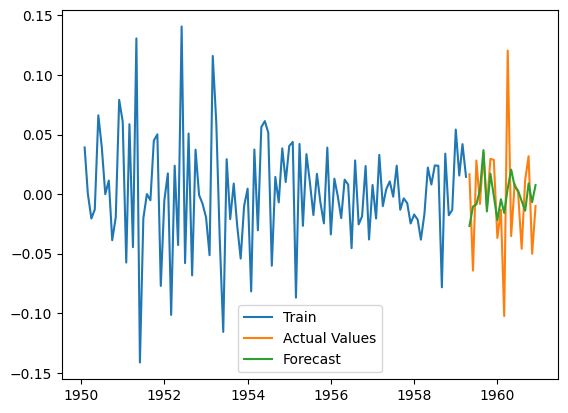

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Initilize the model
#                         p  d  q
model= ARIMA(train, order=(12,1,1))

# Train the model
model_fit= model.fit()

# Predictions

pred= model_fit.forecast(steps=len(test)) # step-> how many future values to forecast

# Plot the forecasting

plt.plot(train.index, train.values, label="Train")
plt.plot(test.index, test.values, label="Actual Values")
# Plot the forecasted values with the actual test dates
plt.plot(test.index, pred, label="Forecast")

plt.legend()
plt.show()


**Instead of directly guessing or Interpreting the p,d,q values from the ACF PACF plots**

**We can use Iter tools**

In [ ]:
import itertools
from sklearn.metrics import *

In [ ]:
# Possible Values
p = range(0, 8)
d = range(1,3)
q = range(0, 8)

# All the possible combination
pdq= list( itertools.product(p,d,q))

rmse_score=[]
orders=[]

# Loop through all the combinations
for i in pdq:
  # Build Model
  model=ARIMA(train, order=i)

  # Train
  model_fit= model.fit()

  # Predictions

  pred=model_fit.forecast(steps=len(test))

  pred.index= test.index   # Add the time as index in Pred

  # RMSE-> ERROR
  error= np.sqrt(mean_squared_error(test, pred))

  # Store the error and order
  orders.append(i)
  rmse_score.append(error)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_date

In [ ]:
# Result Data Frame

result= pd.DataFrame(
    index=orders,
    data=rmse_score,
    columns=["RMSE"]
)

# Sort the result
sorted= result.sort_values(by="RMSE")

# Top models
sorted.head()

,RMSE
"(3, 2, 4)",0.040877
"(2, 2, 5)",0.041902
"(7, 2, 6)",0.042074
"(7, 1, 6)",0.042219
"(6, 2, 6)",0.042321


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


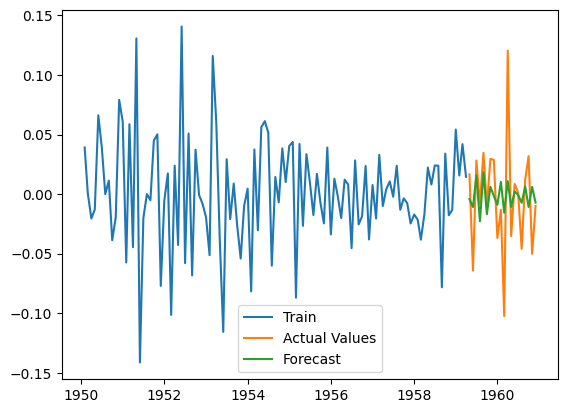

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Initilize the model
#                         p  d  q
model= ARIMA(train, order=(3,2,4))

# Train the model
model_fit= model.fit()

# Predictions

pred= model_fit.forecast(steps=len(test)) # step-> how many future values to forecast

# Plot the forecasting

plt.plot(train.index, train.values, label="Train")
plt.plot(test.index, test.values, label="Actual Values")
# Plot the forecasted values with the actual test dates
plt.plot(test.index, pred, label="Forecast")

plt.legend()
plt.show()


# SARIMA-> Seasonal ARIMA



In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    data,
    order=(p,d,q),
    seasonal_order=(P,D,Q, s)
)

# P, D, Q-> Seasonal order

# s-> cycle lenght ( 12 month, s=12)

# Daily data-> yearly seasonal -> s=365

# Daily data-> weakly seasonal -> s= 7

**Ieration on the Orders**

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
# Possible Values
p = range(0, 3)
d = range(1,2)
q = range(0, 3)

# Seasonal Orders
P= range(0,2)
D= range(0,2)
Q= range(0,2)
s= [12]
# All the possible combination
pdq= list( itertools.product(p,d,q))
seasonal_pdq= list(itertools.product(P,D,Q,s))

rmse_score=[]
orders=[]
seasonal_orders=[]

# Loop through all the combinations
for i in pdq:
  for j in seasonal_pdq:
    # Build Model
    model=SARIMAX(train, order=i,
                  seasonal_order=j,
                  enforce_stationarity=False,
                  enforce_invertibility=False) #

    # Train
    model_fit= model.fit()

    # Predictions

    pred=model_fit.forecast(steps=len(test))

    pred.index= test.index   # Add the time as index in Pred

    # RMSE-> ERROR
    error= np.sqrt(mean_squared_error(test, pred))

    # Store the error and order
    orders.append(i)
    seasonal_orders.append(j)
    rmse_score.append(error)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_date

In [ ]:
# Result Data Frame

result= pd.DataFrame({
    "Order": orders,
    "Seasonal Order":seasonal_orders,
    "Rmse":rmse_score
})

# Sort the result
sorted= result.sort_values(by="Rmse")

# Top models
sorted.head()

,Order,Seasonal Order,Rmse
9,"(0, 1, 1)","(0, 0, 1, 12)",0.042434
25,"(1, 1, 0)","(0, 0, 1, 12)",0.042502
33,"(1, 1, 1)","(0, 0, 1, 12)",0.042583
1,"(0, 1, 0)","(0, 0, 1, 12)",0.042593
5,"(0, 1, 0)","(1, 0, 1, 12)",0.042620


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    data,
    order=(0,1,1),
    seasonal_order=(0,0,1,12),

)

model_fit = model.fit()

pred= model_fit.forecast(steps=len(test))

pred

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


,predicted_mean
1961-01-01,430.355378
1961-02-01,413.420316
1961-03-01,402.127551
1961-04-01,434.613318
1961-05-01,435.721084
1961-06-01,477.205699
1961-07-01,514.204802
1961-08-01,500.803412
1961-09-01,446.347549
1961-10-01,435.487324


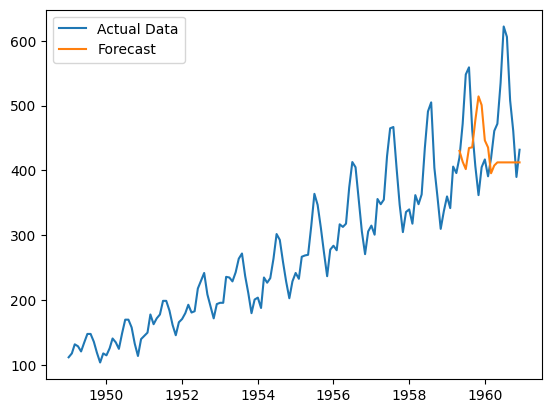

In [ ]:
plt.plot(data.index,data,label="Actual Data")
plt.plot(test.index,pred,label="Forecast")

plt.legend()
plt.show()

## Auto Arima

Tries different models with different orders and tells which model is working the best ( balanced and best) .



In [ ]:
! pip install pmdarima

from pmdarima import auto_arima



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 9.4 MB/s eta 0:00:00


In [ ]:
print(auto_arima)

<function auto_arima at 0x7bde0fd71ee0>


In [ ]:
# Assumption -> Transformation already done

# Fit Auto Arima Model

model = auto_arima(
    train,
    start_p=0, start_q=0,
    max_p=6,   max_q=6,
    d=None,              # Auto differencing

    seasonal=True,
    m=12,            # s-> seasonal cycle
    start_P=0, start_Q=0,
    max_P=2,   max_Q=2,
    D=None            # Auto seasonal Differencing
)

In [ ]:
print(model.summary())

                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  111
Model:             SARIMAX(0, 0, 1)x(0, 0, 1, 12)   Log Likelihood                 206.210
Date:                            Sun, 10 May 2026   AIC                           -406.420
Time:                                    16:45:26   BIC                           -398.291
Sample:                                02-01-1950   HQIC                          -403.122
                                     - 04-01-1959                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.3427      0.085     -4.044      0.000      -0.509      -0.177
ma.S.L12      -0.5584      0.101   

In [ ]:
# SARIMAX(0, 0, 1)x(0, 0, 1, 12)

model= SARIMAX(
    train,
    order=(0,0,1),
    seasonal_order=(0,0,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

model_fit=model.fit()

pred=model_fit.forecast(steps=len(test))


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [ ]:
pred

,predicted_mean
1959-05-01,-0.020131
1959-06-01,-0.014525
1959-07-01,-0.008586
1959-08-01,-0.021468
1959-09-01,0.052279
1959-10-01,-0.013795
1959-11-01,0.009982
1959-12-01,0.019193
1960-01-01,-0.025474
1960-02-01,0.001497


**Undo the log transform using exp()**

In [ ]:
pred_log= pd.Series(pred, index=test.index)
pred_log

,predicted_mean
Month,
1959-05-01,-0.020131
1959-06-01,-0.014525
1959-07-01,-0.008586
1959-08-01,-0.021468
1959-09-01,0.052279
1959-10-01,-0.013795
1959-11-01,0.009982
1959-12-01,0.019193
1960-01-01,-0.025474


In [ ]:
pred_log=np.exp(pred_log)

test_actual= np.exp(test)



In [ ]:
train_actual= np.exp(train)

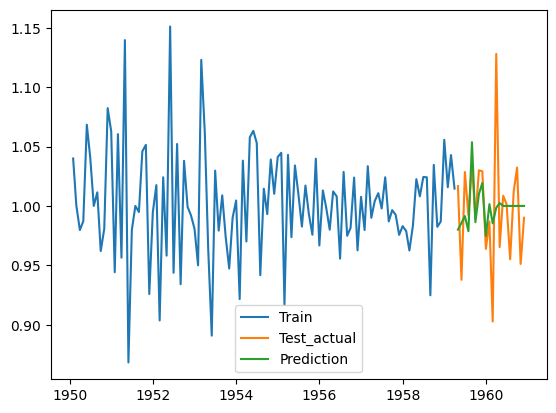

In [ ]:
plt.plot(train_actual, label="Train")
plt.plot(test_actual, label="Test_actual")
plt.plot(pred_log, label="Prediction")

plt.legend()
plt.show()

# ISSUE-> We had manually differenced the data(in order to make it stationary)

# We only needed to log transform( as the models will difference the data themselves)

# **WORK FLOW**

In [ ]:
data

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


In [ ]:
log_data=np.log(data)
log_data

,Passengers
Month,
1949-01-01,4.718499
1949-02-01,4.770685
1949-03-01,4.882802
1949-04-01,4.859812
1949-05-01,4.795791
...,...
1960-08-01,6.406880
1960-09-01,6.230481
1960-10-01,6.133398


In [ ]:
# 85, 15 split

# Rows From start(0) to 85% length-1 => Train
train = log_data.iloc[0 : int(len(df)*0.85)]

# Start from 85% of length go till Last => Test
test= log_data.iloc[int(len(df)*0.85) : ]

print("Train Shape=",train.shape)
print("Test Shape=",test.shape)

Train Shape= (111, 1)
Test Shape= (33, 1)


In [ ]:
model = auto_arima(
    train,
    start_p=0, start_q=0,
    max_p=6,   max_q=6,
    d=None,              # Auto differencing

    seasonal=True,
    m=12,            # s-> seasonal cycle
    start_P=0, start_Q=0,
    max_P=2,   max_Q=2,
    D=None            # Auto seasonal Differencing
)
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                  111
Model:             SARIMAX(2, 0, 0)x(2, 1, 0, 12)   Log Likelihood                 184.886
Date:                            Sun, 10 May 2026   AIC                           -357.772
Time:                                    16:59:09   BIC                           -342.201
Sample:                                01-01-1949   HQIC                          -351.472
                                     - 03-01-1958                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0493      0.024      2.085      0.037       0.003       0.096
ar.L1          0.5905      0.099      5.974      0.000       0.397       0.784
ar.L2          0.1998      0.099      2.016      0.044       0.006       0.394
ar.S.L12      -0.5567      0.116     -4.801      0.000      -0.784      -0.329
ar.S.L24      -0.2689      0.140     -1.925      0.054      -0.543       0.005
sigma2         0.0013      0.000      7.003      0.000       0.001       0.002
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 5.45
Prob(Q):                              0.97   Prob(JB):                         0.07
Heteroskedasticity (H):               0.35   Skew:                             0.21
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.07
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
# SARIMAX(2, 0, 0)x(2, 1, 0, 12)

model= SARIMAX(
    train,
    order=(2,0,0),
    seasonal_order=(2,1,0,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

model_fit=model.fit()

pred=model_fit.forecast(steps=len(test))


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [ ]:
pred= pd.Series(pred, index=test.index)
pred= np.exp(pred)
test= np.exp(test)
train=np.exp(train)

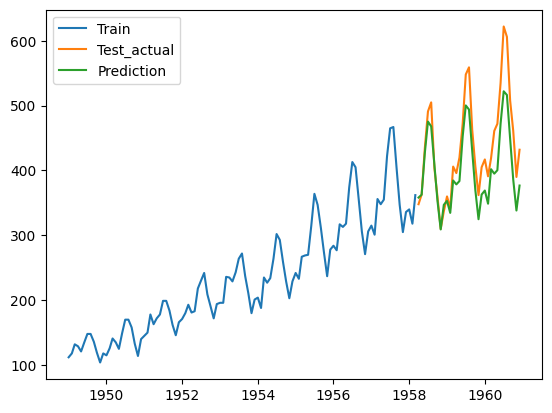

In [ ]:
plt.plot(train, label="Train")
plt.plot(test, label="Test_actual")
plt.plot(pred, label="Prediction")

plt.legend()
plt.show()

# AIC & BIC Scores

They are Evaluation Metics used to compare different models.

For choosing the right model , we have to find a tradeoff betweem goodness of fit and simlicity of model.


Both the scores reward our models based on how well they fit the data, but they peanilize the model for using the number of parameters

A complex model-> Uses a lot of parameters. It can overfit.


We chose the model with the lowest scores.

We want simple models to get better results.

In [ ]:
model_fit.aic

np.float64(-268.5111269395793)

In [ ]:
model_fit.bic

np.float64(-257.05882973383734)